In [203]:
# 1. Instalação de dependências
!pip install mlflow

# 2. Bibliotecas Padrão e Visualização
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 3. PySpark - Sessão e Estrutura
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.sql.types import IntegerType, DoubleType

# 4. PySpark - Funções SQL (Agrupadas)
from pyspark.sql.functions import (
    col, expr, regexp_extract, current_date,
    year as spark_year, udf, isnan
)

# 5. PySpark - Feature Engineering
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler
)

# 6. PySpark - Modelos e Avaliação (Regressão e Classificação)
from pyspark.ml.regression import RandomForestRegressor, LinearRegression
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator

# 7. PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 8. Inicialização da SparkSession
spark = SparkSession.builder \
    .appName("PySpark-Vehicle-Pricing") \
    .getOrCreate()

In [204]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [205]:
dataframe.show(20)

+----------+--------------------+--------------------+--------------------+-----+----+------------+-----+---------+---------+----+--------+------------+------------+----+-----+----+----+-----------+---------+-----------+------+-----+----+----+------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|model|condition|cylinders|fuel|odometer|title_status|transmission| VIN|drive|size|type|paint_color|image_url|description|county|state| lat|long|posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+-----+---------+---------+----+--------+------------+------------+----+-----+----+----+-----------+---------+-----------+------+-----+----+----+------------+
|7222695916|https://prescott....|            prescott|https://prescott....| 6000|NULL|        NULL| NULL|     NULL|     NULL|NULL|    NULL|        NULL|        NULL|NULL| NULL|NULL|NULL|       NULL|     NULL|       NULL|  NULL|  

In [206]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn(
    "year",
    expr("try_cast(regexp_replace(year, '[^0-9]', '') as double)")
)

df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "odometer",
    expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "lat",
    expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "long",
    expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "car_age",
    spark_year(current_date()) - col("year")
)
# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [207]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 100.0) & (col("price") < 1000000.0) &
    (col("year") > 2005.0) & (col("year") <= 2026.0)
)


# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 238716
Filtro aplicado em price: 5499.0 até 35590.0
Filtro aplicado em odometer: 19370.0 até 144404.0
Registros finais: 134883


In [208]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]




In [209]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [210]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [211]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 10
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----+------+-----------+-----+-------+----------+-------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+--------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|drive|  type|paint_color|state|    lat|      long|car_age|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|   type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model_index|
+-

In [212]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(10)


+-------+-------+--------+-------+----------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|    lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|   type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+-------+----------+-----------------+-------------------+-------------+------------------+-------------+--------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|   12.0| 57923.0|  32.59|    -85.48|(297,[236],[1.0])|     (38,[9],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])|(13,[2],[1.0])|    (12,[0],[1.0])|(4270,[19],[1.0])|      (6,[0],[1.0])|            0.0|      176.0|
|22590.0|   16.0| 71229.0|  32.59|    -85.48|(297,[236],[1.0])|     (38,[1],

In [213]:
# Garante que a UDF para ler os vetores OneHot esteja definida
get_index = udf(lambda v: float(v.indices[0]) if len(v.indices) > 0 else -1.0, DoubleType())

# Combinação de todos os filtros em uma única operação
df_pre_treino = df_pre_treino \
    .withColumn("paint_temp_idx", get_index(col("paint_color_onehot"))) \
    .withColumn("drive_temp_idx", get_index(col("drive_onehot"))) \
    .filter(
        (~col("paint_temp_idx").isin([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])) &
        (~col("drive_temp_idx").isin([2.0])) &
        (~col("condition_index").isin([2.0, 3.0, 4.0, 5.0]))
    ) \
    .drop("paint_temp_idx", "drive_temp_idx")

# Opcional: Verifique o resultado
# print(f"Linhas após filtros: {df_pre_treino.count()}")

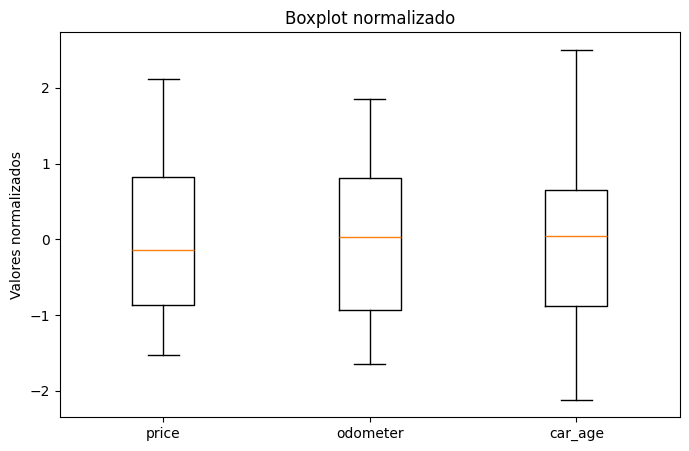

In [214]:
data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

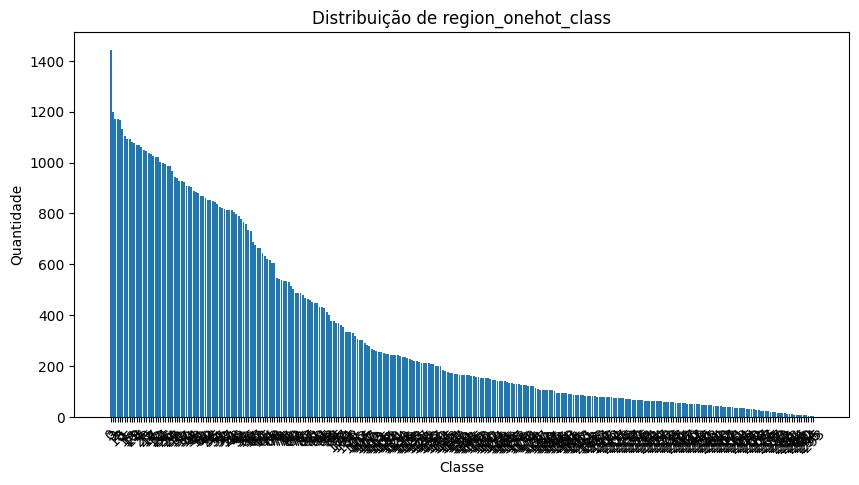

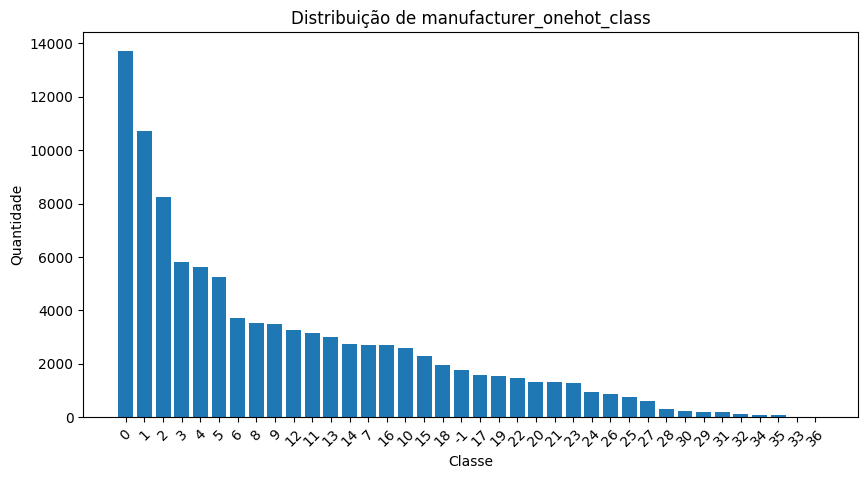

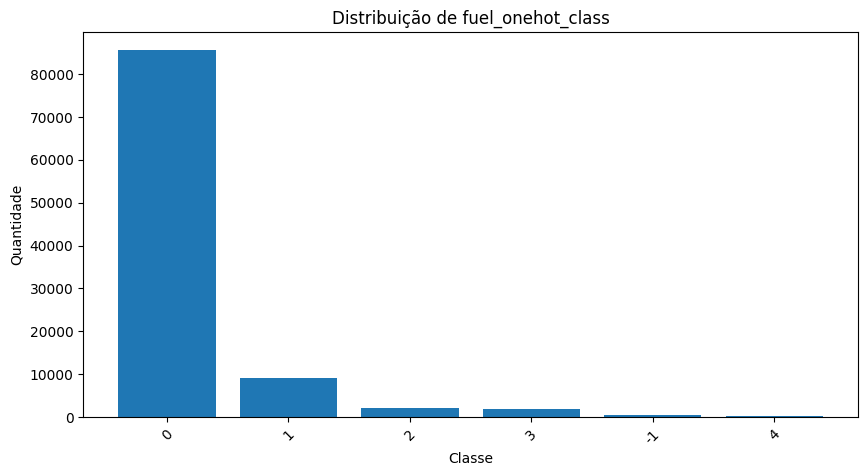

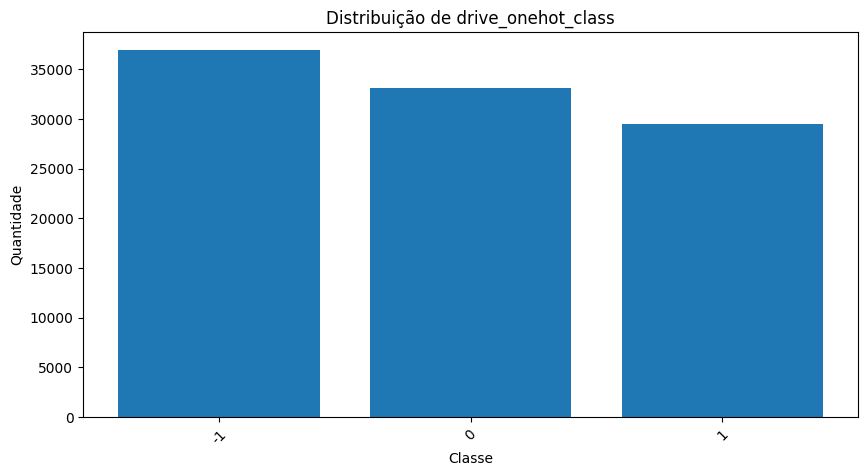

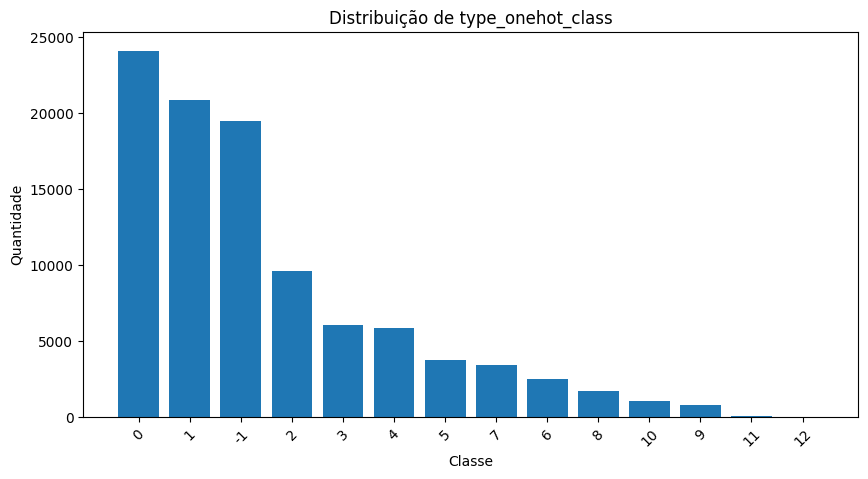

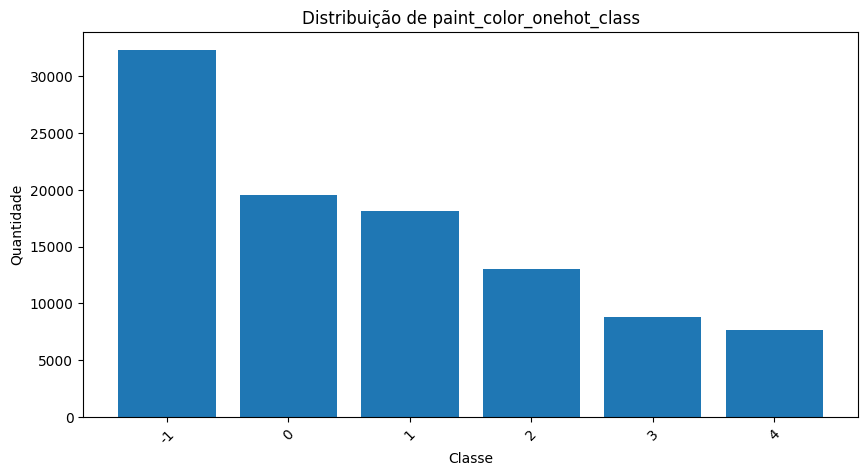

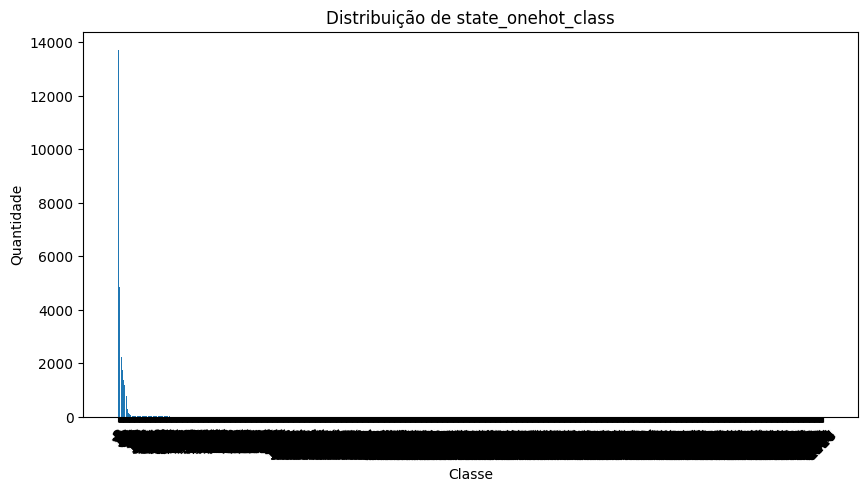

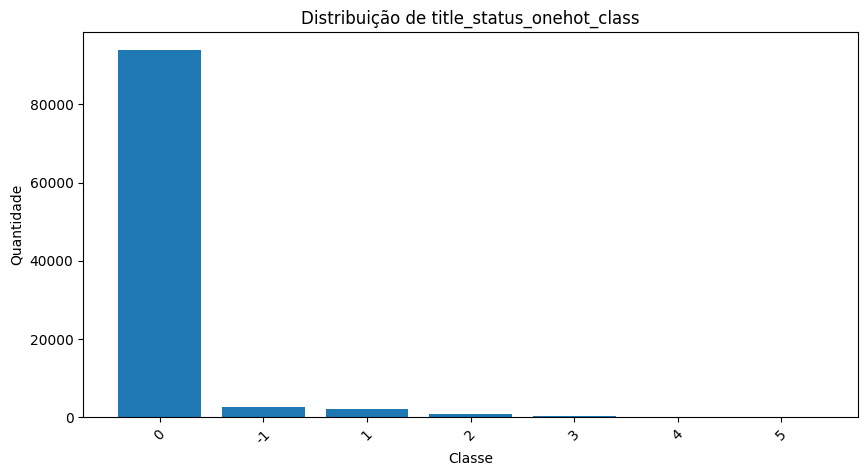

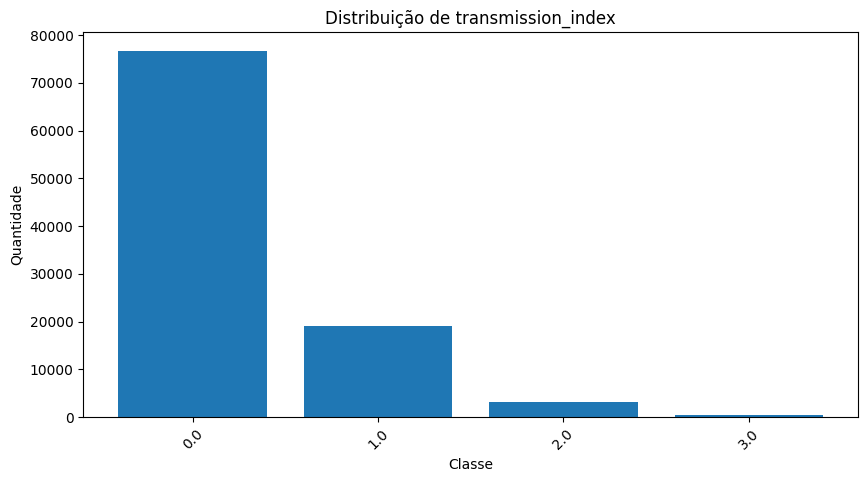

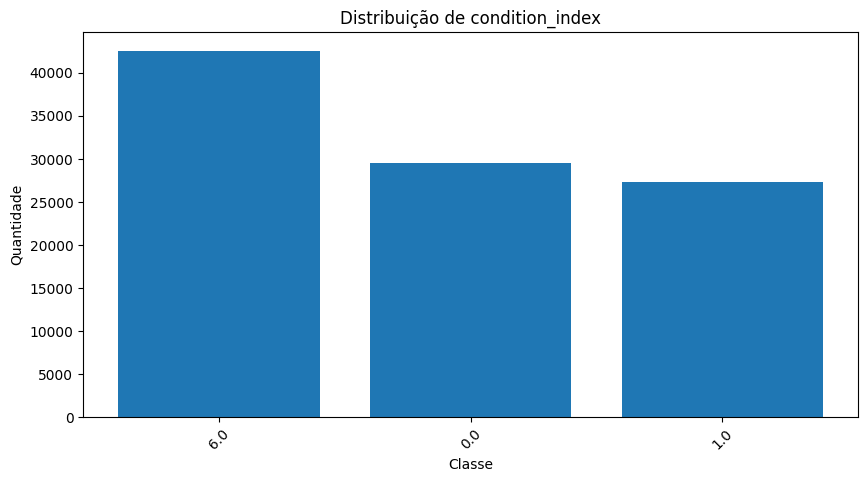

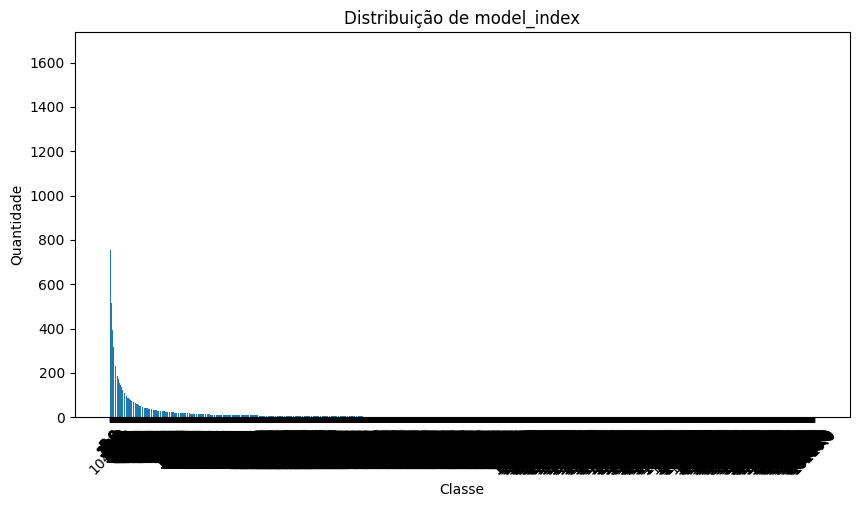

In [215]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

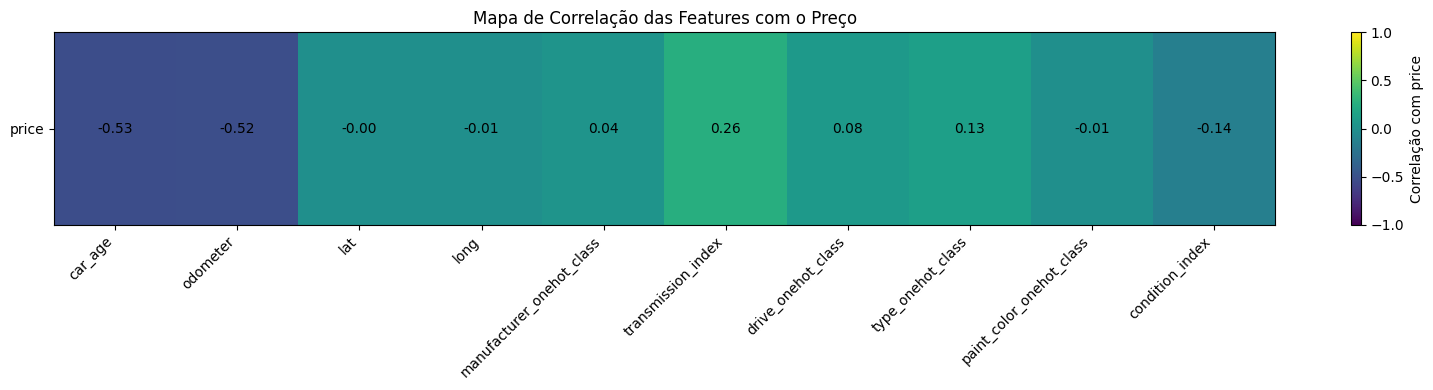

In [216]:
def onehot_to_index(v):
    if v is None:
        return None

    arr = v.toArray()

    if arr.sum() == 0:
        return -1

    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

df_corr = df_pre_treino

onehot_cols = [
    "manufacturer_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot"
]

for c in onehot_cols:
    df_corr = df_corr.withColumn(
        c + "_class",
        onehot_to_index_udf(col(c))
    )

corr_cols = [
    "car_age",
    "odometer",
    "lat",
    "long",
    "manufacturer_onehot_class",
    "transmission_index",
    "drive_onehot_class",
    "type_onehot_class",
    "paint_color_onehot_class",
    "condition_index"
]

cols_necessarias = ["price"] + corr_cols

df_corr = df_corr.dropna(subset=cols_necessarias)

for c in cols_necessarias:
    df_corr = df_corr.filter(~isnan(col(c)))

correlations = []

for c in corr_cols:
    corr_value = df_corr.stat.corr("price", c)

    if corr_value is None:
        corr_value = 0.0

    correlations.append(corr_value)

corr_matrix = np.array([correlations])

plt.figure(figsize=(16, 4))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação com price")

plt.xticks(
    ticks=np.arange(len(corr_cols)),
    labels=corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks([0], ["price"])
plt.title("Mapa de Correlação das Features com o Preço")

for i, value in enumerate(correlations):
    plt.text(
        i,
        0,
        f"{value:.2f}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

In [217]:
df_pre_treino.count()


99465

Treinamento de Random Forest

In [218]:
# Lista dos atributos que você definiu (Features)
feature_cols = [
    "car_age",
    "odometer",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "condition_index"
]

# Assembler: agrupa tudo em uma coluna chamada 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transforma o DataFrame filtrado
df_model = assembler.transform(df_pre_treino).select("features", "price")

In [219]:
# Lista de colunas que não podem ser nulas para o treino
cols_to_check = [
    "car_age",
    "odometer",
    "transmission_index",
    "type_onehot",
    "drive_onehot",
    "condition_index"
]

# Remove as linhas que possuem null em qualquer uma dessas colunas
df_pre_treino_clean = df_pre_treino.dropna(subset=cols_to_check)

# Agora use o df_pre_treino_clean no seu transform
df_model = assembler.transform(df_pre_treino_clean).select("features", "price")

In [220]:
# 80% para treino e 20% para teste
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

In [221]:
try:
    df_pre_treino.unpersist()
except:
    pass

train_data_repartitioned = train_data.repartition(8)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="price",
    numTrees=50,
    maxDepth=13,
    seed=42
)

model = rf.fit(train_data_repartitioned)

In [222]:
# Previsões no conjunto de teste
predictions = model.transform(test_data)

# Avaliadores
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE (Erro médio): {rmse:.2f}")
print(f"R² (Precisão do modelo): {r2:.2f}")

# Mostrar as primeiras comparações entre Real e Previsto
predictions.select("price", "prediction").show(10)

RMSE (Erro médio): 4755.55
R² (Precisão do modelo): 0.67
+-------+------------------+
|  price|        prediction|
+-------+------------------+
| 6750.0|24844.479343438077|
|15400.0|16693.047327844844|
|16200.0|15775.659891357269|
| 8999.0|16876.709018116064|
| 7900.0| 13078.32206585881|
|14500.0|16207.381622225204|
|13750.0|11726.329992760344|
| 6800.0|11431.841206084086|
| 7000.0| 9537.880165546143|
| 6900.0|12076.326433362254|
+-------+------------------+
only showing top 10 rows


Regressão Linear

In [223]:
# 1. Definimos a lista de colunas (Removendo o 'price' da lista de entrada)
feature_cols = [
    "car_age",
    "odometer",
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot",
    "condition_index",
    "model_index"
]

# 2. Criar o Assembler
# Ele vai juntar todas as colunas numéricas e os vetores OneHot em uma única coluna 'features'
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep" # Garante que não trave se houver algum valor nulo residual
)

# 3. Transformar os dados
df_model = assembler.transform(df_pre_treino).select("features", "price")

# 4. Divisão Treino e Teste (80/20)
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# 5. Configuração da Regressão Linear
# Usamos elasticNetParam=0.8 e regParam=0.1 para lidar com a alta dimensionalidade
lr = LinearRegression(
    featuresCol="features",
    labelCol="price",
    maxIter=100,
    regParam=0.1,       # Ajuda a lidar com o excesso de colunas (OneHot)
    elasticNetParam=0.8 # Combina L1 e L2 para selecionar as melhores features
)

# 6. Treinamento
lr_model = lr.fit(train_data)

# 7. Previsões e Avaliação
predictions = lr_model.transform(test_data)

evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)

print("="*40)
print("REGRESSÃO LINEAR: LISTA COMPLETA")
print(f"R²:   {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print("="*40)

# Exibir comparativo real vs previsto
predictions.select("price", "prediction").show(10)

REGRESSÃO LINEAR: LISTA COMPLETA
R²:   0.7078
RMSE: $4,483.67
+-------+------------------+
|  price|        prediction|
+-------+------------------+
| 6194.0| 9436.926584605262|
|15995.0|11206.407742380667|
|33933.0| 28167.81948926486|
|18995.0|17648.105988033974|
|13995.0| 20467.88721821356|
|11991.0|20252.634599212688|
|18995.0|13039.776362791315|
|17995.0| 20981.60745871776|
|11500.0| 16536.91020067004|
|29900.0| 19570.40352094386|
+-------+------------------+
only showing top 10 rows


Modelo de rede neural

In [227]:
# Lista de features otimizada (10 colunas base)
feature_cols = [
    "car_age",
    "odometer",
    "manufacturer_onehot",
    "transmission_index",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "title_status_onehot",
    "condition_index",
    "model_index"
]

# Assembler atualizado
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip" # Remove linhas com nulos automaticamente para evitar erro na Regressão Linear
)

# Criando o DataFrame para o modelo
# Usamos o dropna aqui para garantir que o PyTorch não receba NaNs
df_model = assembler.transform(df_pre_treino).select("features", "price").dropna()

# Verificação de segurança: Quantas colunas o vetor final tem agora?
dimensoes = len(df_model.select("features").first()[0].toArray())

Iniciando treinamento no cpu...
Época 00 | Loss Treino: 0.5214 | Loss Val: 0.3142
Época 01 | Loss Treino: 0.3267 | Loss Val: 0.2903
Época 02 | Loss Treino: 0.3048 | Loss Val: 0.2785
Época 03 | Loss Treino: 0.2935 | Loss Val: 0.2706
Época 04 | Loss Treino: 0.2849 | Loss Val: 0.2661
Época 05 | Loss Treino: 0.2792 | Loss Val: 0.2626
Época 06 | Loss Treino: 0.2733 | Loss Val: 0.2594
Época 07 | Loss Treino: 0.2695 | Loss Val: 0.2560
Época 08 | Loss Treino: 0.2669 | Loss Val: 0.2555
Época 09 | Loss Treino: 0.2625 | Loss Val: 0.2535


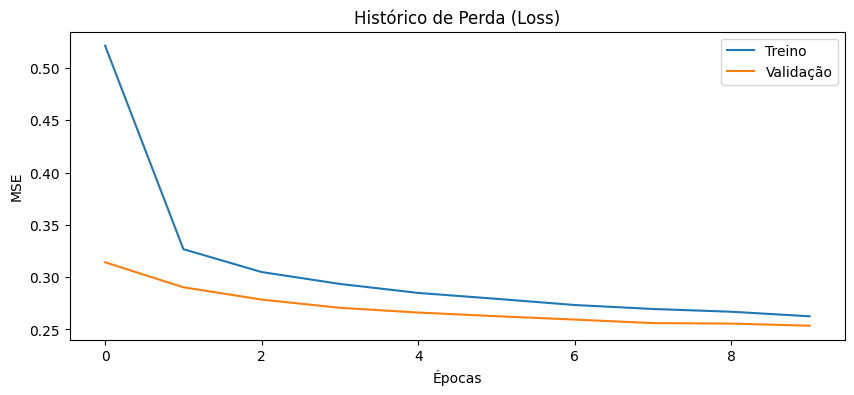


R² Score: 0.7466
RMSE: $4,171.69


In [232]:
# ============================================================
# 1. PREPARAÇÃO DAS FEATURES (LIGHTWEIGHT)
# ============================================================
from pyspark.ml.feature import VectorAssembler

# Sua lista de features otimizada
feature_cols = [
    "car_age", "odometer", "manufacturer_onehot", "transmission_index",
    "drive_onehot", "type_onehot", "paint_color_onehot",
    "title_status_onehot", "condition_index", "model_index"
]

# Configurando o Assembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Criando o DataFrame final e coletando para o Python (NumPy)
# O .dropna() aqui é vital para não quebrar a rede neural
df_model_spark = assembler.transform(df_pre_treino).select("features", "price").dropna()
dados_coletados = df_model_spark.collect()

X_raw = np.array([row["features"].toArray() for row in dados_coletados], dtype=np.float32)
y_raw = np.array([row["price"] for row in dados_coletados], dtype=np.float32).reshape(-1, 1)

# ============================================================
# 2. NORMALIZAÇÃO E DIVISÃO (TREINO/TESTE)
# ============================================================
# Normalização Z-Score
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_std[X_std == 0] = 1.0
X_scaled = (X_raw - X_mean) / X_std

y_mean, y_std = y_raw.mean(), y_raw.std()
y_scaled = (y_raw - y_mean) / y_std

# Split 80/20
indices = np.random.permutation(len(X_scaled))
split = int(0.8 * len(X_scaled))
train_idx, test_idx = indices[:split], indices[split:]

# Preparação para o PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_scaled[train_idx])
y_train_t = torch.tensor(y_scaled[train_idx])
X_test_t = torch.tensor(X_scaled[test_idx]).to(device)
y_test_t = torch.tensor(y_scaled[test_idx]).to(device)

# DataLoader (Batch de 1024 para velocidade)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=1024, shuffle=True)

# ============================================================
# 3. DEFINIÇÃO DO MODELO (ARQUITETURA)
# ============================================================
class CarPriceNet(nn.Module):
    def __init__(self, input_dim):
        super(CarPriceNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = CarPriceNet(X_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ============================================================
# 4. LOOP DE TREINAMENTO COM HISTÓRICO DE LOSS
# ============================================================
epochs = 10
train_losses = []
val_losses = []

print(f"Iniciando treinamento no {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)

    avg_train_loss = running_loss / len(train_idx)
    train_losses.append(avg_train_loss)

    # Validação (ver como a rede se sai com dados novos)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        v_loss = criterion(val_pred, y_test_t)
        val_losses.append(v_loss.item())

    if epoch % 1 == 0:
        print(f"Época {epoch:02d} | Loss Treino: {avg_train_loss:.4f} | Loss Val: {v_loss.item():.4f}")

# ============================================================
# 5. RESULTADOS E GRÁFICOS
# ============================================================
# Plot das curvas de aprendizado
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title("Histórico de Perda (Loss)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Avaliação Final em Dólares
model.eval()
with torch.no_grad():
    preds = model(X_test_t).cpu().numpy()

y_real = (y_test_t.cpu().numpy() * y_std) + y_mean
y_pred = (preds * y_std) + y_mean

print("\n" + "="*30)
print(f"R² Score: {r2_score(y_real, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(np.mean((y_real - y_pred)**2)):,.2f}")
print("="*30)